In [43]:

# Core imports
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D plotting)

import gymnasium as gym

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [44]:

# ---------------------------------------------------------------------
# Quick inspection summary from the provided notebook
# ---------------------------------------------------------------------
inspection_points = {
    "Relevant source cells": [29, 30, 31, 32, 34],
    "Blackjack state": "(player_sum, dealer_showing, usable_ace)",
    "Actions": {0: "Stick", 1: "Hit"},
    "Reward structure": "+1 win, 0 draw, -1 loss",
    "Important takeaway": "The provided notebook already had a small Blackjack MC-control skeleton, but only for a short run.",
    "What this notebook adds": "500k+ training, first-visit updates, value surfaces, policy comparison, learning curves, and epsilon experiments."
}

for k, v in inspection_points.items():
    print(f"{k}: {v}")


Relevant source cells: [29, 30, 31, 32, 34]
Blackjack state: (player_sum, dealer_showing, usable_ace)
Actions: {0: 'Stick', 1: 'Hit'}
Reward structure: +1 win, 0 draw, -1 loss
Important takeaway: The provided notebook already had a small Blackjack MC-control skeleton, but only for a short run.
What this notebook adds: 500k+ training, first-visit updates, value surfaces, policy comparison, learning curves, and epsilon experiments.



## 1. Environment and helper functions

We use **Gymnasium's `Blackjack-v1`** environment.

The state is:
- `player_sum`
- `dealer_showing`
- `usable_ace`

The action space is:
- `0 = stick`
- `1 = hit`

We use an **ε-soft policy** during training. That means:
- with high probability, the agent chooses the greedy action,
- with small probability `ε`, it explores.


In [45]:

# Create the environment
env = gym.make("Blackjack-v1")

print("Observation space example after reset:")
state, info = env.reset(seed=42)
print("Initial state:", state)
print("Action space size:", env.action_space.n)


Observation space example after reset:
Initial state: (15, 2, 0)
Action space size: 2


In [46]:

# ---------------------------------------------------------------------
# Policy helpers
# ---------------------------------------------------------------------

def argmax_tie_break(q_values, rng):
    """Return a random argmax to avoid always preferring the first action."""
    max_val = np.max(q_values)
    candidates = np.flatnonzero(q_values == max_val)
    return int(rng.choice(candidates))


def epsilon_greedy_action(Q, state, epsilon, n_actions, rng):
    """Sample an action from an epsilon-greedy policy derived from Q."""
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    return argmax_tie_break(Q[state], rng)


def make_epsilon_schedule(schedule_type="fixed", start=0.1, end=0.01, decay_fraction=0.8):
    """
    Returns a function epsilon(episode_idx, total_episodes).
    Supported schedules: fixed, linear, exponential.
    """
    def fixed(ep, total_eps):
        return float(start)

    def linear(ep, total_eps):
        decay_episodes = max(1, int(total_eps * decay_fraction))
        progress = min(ep / decay_episodes, 1.0)
        return float(start + (end - start) * progress)

    def exponential(ep, total_eps):
        decay_episodes = max(1, int(total_eps * decay_fraction))
        progress = min(ep / decay_episodes, 1.0)
        if start <= 0 or end <= 0:
            return float(end)
        value = start * ((end / start) ** progress)
        return float(value)

    schedules = {
        "fixed": fixed,
        "linear": linear,
        "exponential": exponential,
    }
    if schedule_type not in schedules:
        raise ValueError(f"Unknown schedule_type: {schedule_type}")
    return schedules[schedule_type]


In [47]:

# ---------------------------------------------------------------------
# Episode generation
# ---------------------------------------------------------------------

def generate_episode(env, Q, epsilon, rng):
    """
    Generate one full episode using the current epsilon-soft policy.

    Returns
    -------
    episode : list of (state, action, reward)
        Full trajectory stored in a Python list.
    """
    episode = []
    state, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = epsilon_greedy_action(Q, state, epsilon, env.action_space.n, rng)
        next_state, reward, terminated, truncated, info = env.step(action)
        episode.append((state, action, reward))
        state = next_state

    return episode


In [48]:

# ---------------------------------------------------------------------
# First-visit Monte Carlo control
# ---------------------------------------------------------------------

def first_visit_mc_control(
    env,
    n_episodes=500_000,
    gamma=1.0,
    schedule_type="fixed",
    epsilon_start=0.1,
    epsilon_end=0.01,
    decay_fraction=0.8,
    seed=123,
    log_every=50_000,
):
    """
    On-policy first-visit Monte Carlo control with epsilon-soft policies.
    """
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n

    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    epsilon_fn = make_epsilon_schedule(
        schedule_type=schedule_type,
        start=epsilon_start,
        end=epsilon_end,
        decay_fraction=decay_fraction,
    )

    episode_returns = []
    episode_lengths = []
    epsilon_history = []
    checkpoints = []

    start_time = time.time()

    for ep in range(1, n_episodes + 1):
        epsilon = epsilon_fn(ep - 1, n_episodes)
        epsilon_history.append(epsilon)

        episode = generate_episode(env, Q, epsilon, rng)

        total_reward = sum(r for _, _, r in episode)
        episode_returns.append(total_reward)
        episode_lengths.append(len(episode))

        G = 0.0
        visited_sa = set()

        # Work backward through the episode to compute returns
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            # first-visit MC: only update when this (s,a) is the first occurrence
            # from the start of the episode, which is equivalent to the last one
            # encountered when scanning backward and guarding with a set
            if (state, action) not in visited_sa:
                visited_sa.add((state, action))
                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1
                Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]

        if ep % log_every == 0 or ep == 1 or ep == n_episodes:
            elapsed = time.time() - start_time
            recent = np.mean(episode_returns[max(0, ep - log_every):ep])
            recent_len = np.mean(episode_lengths[max(0, ep - log_every):ep])
            checkpoints.append({
                "episode": ep,
                "epsilon": epsilon,
                "avg_return_recent": recent,
                "avg_length_recent": recent_len,
                "visited_states": len(Q),
                "elapsed_sec": elapsed,
            })
            print(
                f"Episode {ep:>7,d} | epsilon={epsilon:.4f} | "
                f"recent avg return={recent:+.4f} | "
                f"recent avg length={recent_len:.2f} | "
                f"visited states={len(Q):>4d} | elapsed={elapsed:.1f}s"
            )

    policy = {state: int(np.argmax(actions)) for state, actions in Q.items()}

    results = {
        "Q": Q,
        "policy": policy,
        "episode_returns": np.array(episode_returns, dtype=np.float64),
        "episode_lengths": np.array(episode_lengths, dtype=np.int32),
        "epsilon_history": np.array(epsilon_history, dtype=np.float64),
        "checkpoints": pd.DataFrame(checkpoints),
        "config": {
            "n_episodes": n_episodes,
            "gamma": gamma,
            "schedule_type": schedule_type,
            "epsilon_start": epsilon_start,
            "epsilon_end": epsilon_end,
            "decay_fraction": decay_fraction,
            "seed": seed,
        }
    }
    return results


In [49]:

# ---------------------------------------------------------------------
# Utility functions for smoothing and extracting value / policy tables
# ---------------------------------------------------------------------

def moving_average(x, window=10_000):
    x = np.asarray(x, dtype=np.float64)
    if window <= 1:
        return x.copy()
    if len(x) < window:
        return np.array([])
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def state_value_from_Q(Q, state):
    return np.max(Q[state]) if state in Q else 0.0


def build_value_grid(Q, usable_ace=True):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    X, Y = np.meshgrid(dealer_cards, player_sums)
    Z = np.zeros_like(X, dtype=np.float64)

    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            state = (int(ps), int(dc), bool(usable_ace))
            Z[i, j] = state_value_from_Q(Q, state)
    return X, Y, Z


def build_policy_grid(policy, usable_ace=True):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)

    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            state = (int(ps), int(dc), bool(usable_ace))
            grid[i, j] = policy.get(state, 1)  # default to hit if unseen
    return grid



## 2. Main training run (500,000 episodes)

It satisfies the requirement to train for **at least 500,000 episodes**.

Default setup here:
- `gamma = 1.0`
- first-visit MC control
- on-policy ε-soft behavior
- **linear ε decay** from `0.10` to `0.01`


In [50]:

main_results = first_visit_mc_control(
    env=env,
    n_episodes=500_000,
    gamma=1.0,
    schedule_type="exponential",
    epsilon_start=0.10,
    epsilon_end=0.01,
    decay_fraction=0.80,
    seed=123,
    log_every=50_000,
)


Episode       1 | epsilon=0.1000 | recent avg return=-1.0000 | recent avg length=1.00 | visited states=   1 | elapsed=0.0s
Episode  50,000 | epsilon=0.0750 | recent avg return=-0.1065 | recent avg length=1.44 | visited states= 280 | elapsed=1.4s
Episode 100,000 | epsilon=0.0562 | recent avg return=-0.0793 | recent avg length=1.49 | visited states= 280 | elapsed=2.9s
Episode 150,000 | epsilon=0.0422 | recent avg return=-0.0702 | recent avg length=1.50 | visited states= 280 | elapsed=4.4s
Episode 200,000 | epsilon=0.0316 | recent avg return=-0.0761 | recent avg length=1.51 | visited states= 280 | elapsed=5.9s
Episode 250,000 | epsilon=0.0237 | recent avg return=-0.0585 | recent avg length=1.52 | visited states= 280 | elapsed=7.5s
Episode 300,000 | epsilon=0.0178 | recent avg return=-0.0612 | recent avg length=1.52 | visited states= 280 | elapsed=9.0s
Episode 350,000 | epsilon=0.0133 | recent avg return=-0.0585 | recent avg length=1.51 | visited states= 280 | elapsed=10.5s
Episode 400,000

In [51]:

print("Training summary:")
for k, v in main_results["config"].items():
    print(f"{k}: {v}")

print("Checkpoint table:")
display(main_results["checkpoints"])

returns_arr = main_results["episode_returns"]
print(f"Overall mean return: {returns_arr.mean():+.4f}")
print(f"Win rate estimate  : {(returns_arr == 1).mean():.4f}")
print(f"Draw rate estimate : {(returns_arr == 0).mean():.4f}")
print(f"Loss rate estimate : {(returns_arr == -1).mean():.4f}")


Training summary:
n_episodes: 500000
gamma: 1.0
schedule_type: exponential
epsilon_start: 0.1
epsilon_end: 0.01
decay_fraction: 0.8
seed: 123
Checkpoint table:


,episode,epsilon,avg_return_recent,avg_length_recent,visited_states,elapsed_sec
0,1,0.100000,-1.00000,1.00000,1,0.002494
1,50000,0.074990,-0.10650,1.44336,280,1.437593
2,100000,0.056234,-0.07928,1.49102,280,2.936523
3,150000,0.042170,-0.07022,1.50330,280,4.425202
4,200000,0.031623,-0.07610,1.50564,280,5.947827
5,250000,0.023714,-0.05848,1.51574,280,7.462659
6,300000,0.017783,-0.06124,1.51992,280,9.004205
7,350000,0.013335,-0.05854,1.50664,280,10.519966
8,400000,0.010000,-0.05920,1.51376,280,12.072034
9,450000,0.010000,-0.05490,1.52116,280,13.612551


Overall mean return: -0.0674
Win rate estimate  : 0.4239
Draw rate estimate : 0.0848
Loss rate estimate : 0.4913


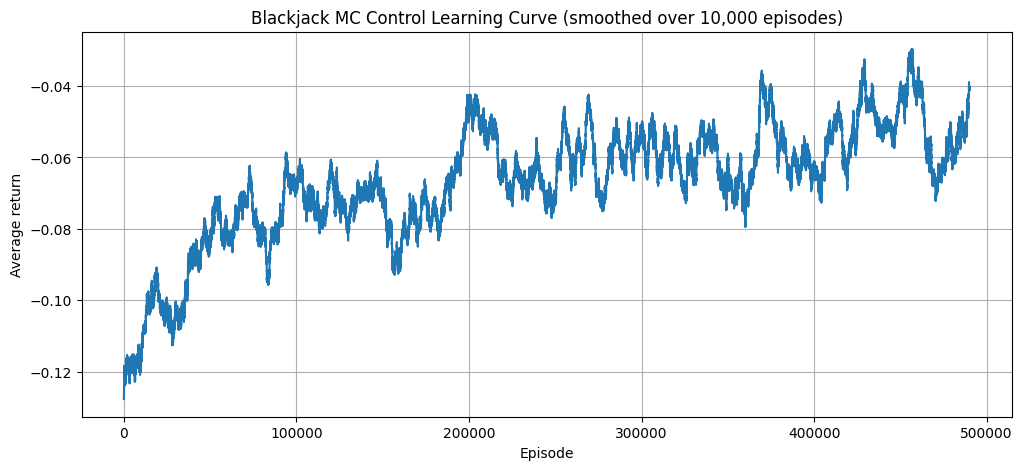

In [52]:

# Learning curve for episode returns
window = 10_000
smoothed = moving_average(main_results["episode_returns"], window=window)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, len(smoothed) + 1), smoothed)
plt.title(f"Blackjack MC Control Learning Curve (smoothed over {window:,} episodes)")
plt.xlabel("Episode")
plt.ylabel("Average return")
plt.show()


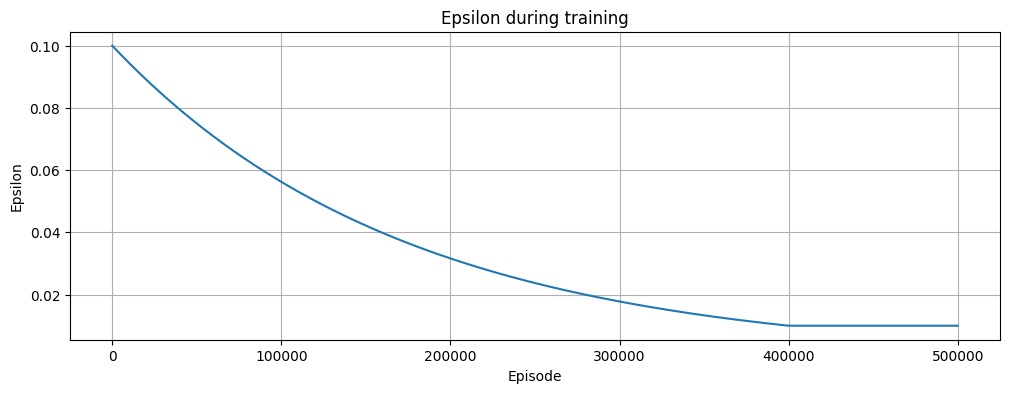

In [53]:

# Epsilon schedule curve
plt.figure(figsize=(12, 4))
plt.plot(main_results["epsilon_history"])
plt.title("Epsilon during training")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()


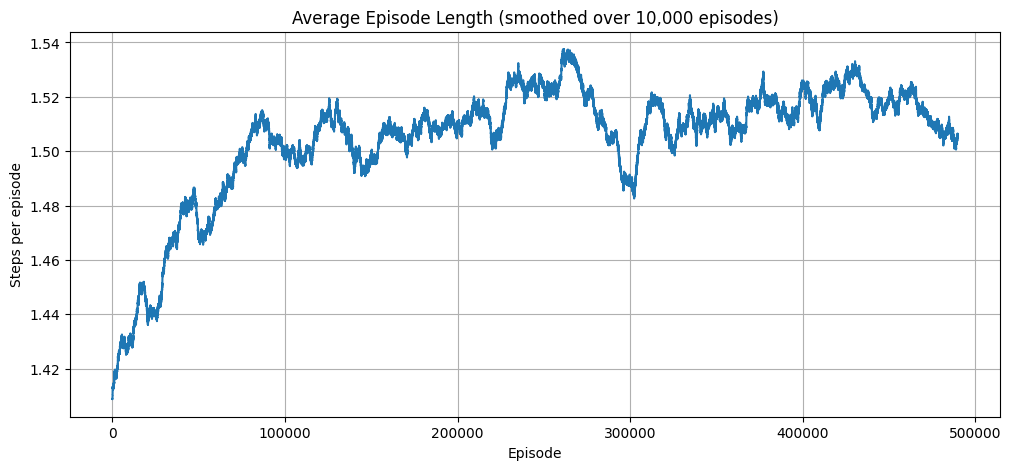

In [54]:

# Episode length behavior
len_smoothed = moving_average(main_results["episode_lengths"], window=window)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, len(len_smoothed) + 1), len_smoothed)
plt.title(f"Average Episode Length (smoothed over {window:,} episodes)")
plt.xlabel("Episode")
plt.ylabel("Steps per episode")
plt.show()



## 3. Learned value function as 3D surfaces

We now visualize the learned value function:

- one surface for **usable ace = True**,
- one surface for **usable ace = False**.

This is the standard way of viewing Monte Carlo Blackjack results.


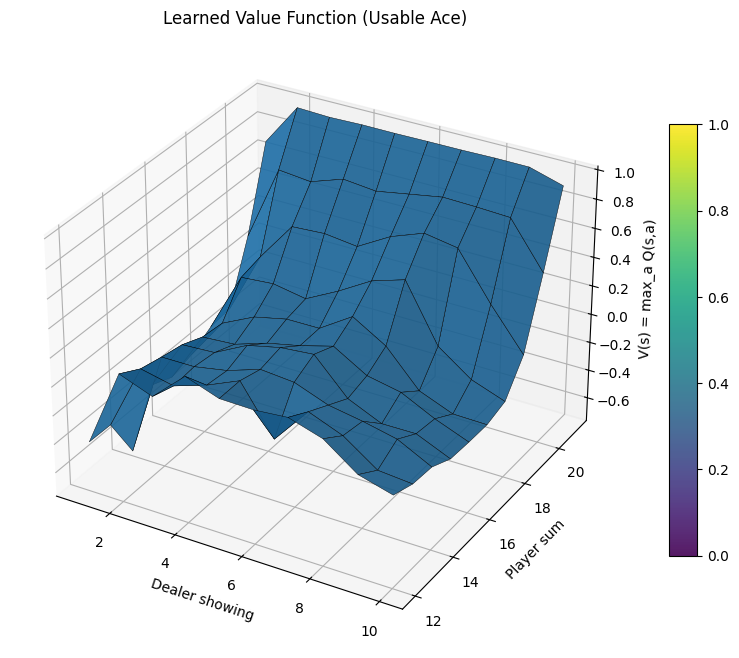

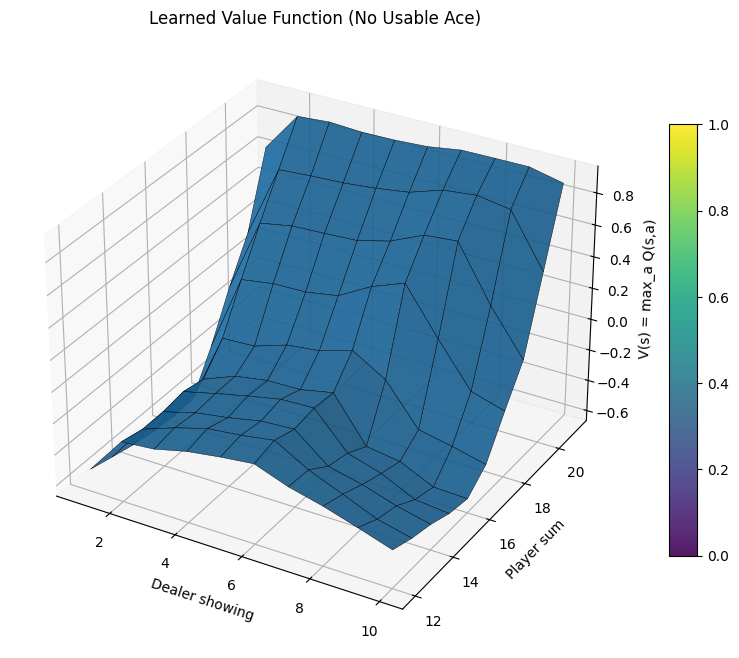

In [55]:

def plot_value_surface(Q, usable_ace=True, title_suffix=""):
    X, Y, Z = build_value_grid(Q, usable_ace=usable_ace)

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, edgecolor="black", linewidth=0.3, alpha=0.9)
    ax.set_title(f"Learned Value Function ({'Usable Ace' if usable_ace else 'No Usable Ace'}) {title_suffix}")
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_zlabel("V(s) = max_a Q(s,a)")
    fig.colorbar(surf, shrink=0.7, aspect=15)
    plt.show()

plot_value_surface(main_results["Q"], usable_ace=True)
plot_value_surface(main_results["Q"], usable_ace=False)



## 4. Learned policy heatmaps

Below, `0 = stick` and `1 = hit`.


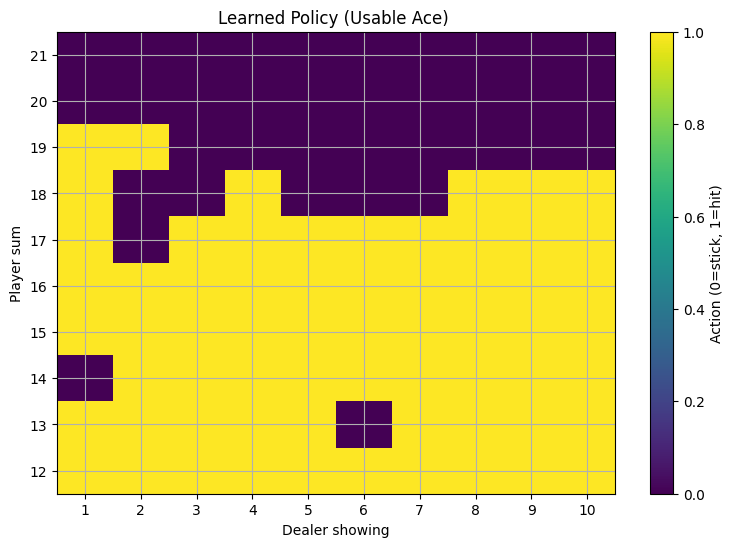

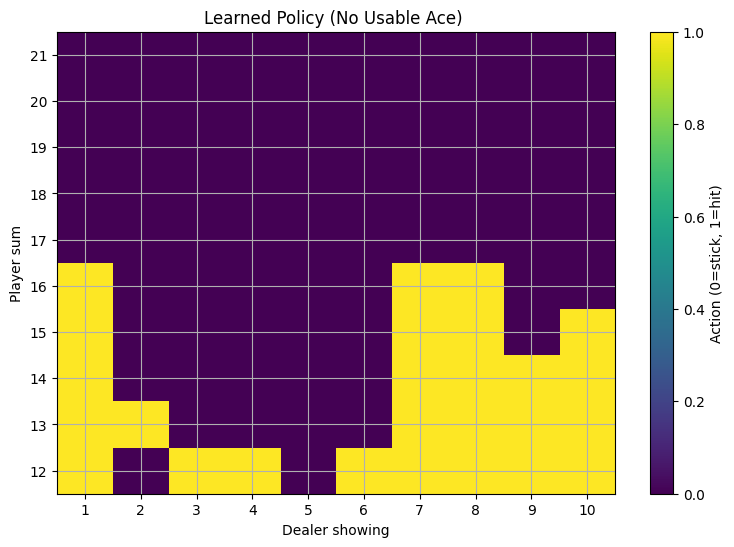

In [56]:

def plot_policy_heatmap(policy, usable_ace=True, title_suffix=""):
    grid = build_policy_grid(policy, usable_ace=usable_ace)
    plt.figure(figsize=(9, 6))
    plt.imshow(grid, origin="lower", aspect="auto")
    plt.colorbar(label="Action (0=stick, 1=hit)")
    plt.xticks(np.arange(10), labels=np.arange(1, 11))
    plt.yticks(np.arange(10), labels=np.arange(12, 22))
    plt.xlabel("Dealer showing")
    plt.ylabel("Player sum")
    plt.title(f"Learned Policy ({'Usable Ace' if usable_ace else 'No Usable Ace'}) {title_suffix}")
    plt.show()

plot_policy_heatmap(main_results["policy"], usable_ace=True)
plot_policy_heatmap(main_results["policy"], usable_ace=False)



## 5. Compare learned policy with a simplified basic Blackjack strategy

To keep the comparison transparent, we use a **simple basic-strategy approximation**:

### Hard hands (no usable ace)
- stick on 17+
- stick on 13–16 against dealer 2–6
- stick on 12 against dealer 4–6
- otherwise hit

### Soft hands (usable ace)
- stick on 19+
- stick on soft 18 against dealer 2, 7, 8
- otherwise hit

This is not a full casino chart with doubles/splits/surrender because the Gymnasium environment only supports **hit** and **stick**.


In [57]:

def basic_strategy_action(player_sum, dealer_card, usable_ace):
    # 0 = stick, 1 = hit
    if usable_ace:
        # Soft hands
        if player_sum >= 19:
            return 0
        if player_sum == 18 and dealer_card in [2, 7, 8]:
            return 0
        return 1
    else:
        # Hard hands
        if player_sum >= 17:
            return 0
        if 13 <= player_sum <= 16 and 2 <= dealer_card <= 6:
            return 0
        if player_sum == 12 and 4 <= dealer_card <= 6:
            return 0
        return 1


def build_basic_strategy_grid(usable_ace=True):
    grid = np.zeros((10, 10), dtype=int)
    for i, ps in enumerate(range(12, 22)):
        for j, dc in enumerate(range(1, 11)):
            grid[i, j] = basic_strategy_action(ps, dc, usable_ace)
    return grid


def compare_policy_to_basic(learned_policy, usable_ace=True):
    learned = build_policy_grid(learned_policy, usable_ace=usable_ace)
    basic = build_basic_strategy_grid(usable_ace=usable_ace)
    match = (learned == basic)
    agreement = match.mean()
    diff_count = np.size(match) - match.sum()
    return learned, basic, match, agreement, diff_count


In [58]:

for ace_flag in [True, False]:
    learned, basic, match, agreement, diff_count = compare_policy_to_basic(
        main_results["policy"], usable_ace=ace_flag
    )
    print(f"Usable ace = {ace_flag}: agreement with simplified basic strategy = {agreement:.2%} ({100 - diff_count}/{100} cells match)")


Usable ace = True: agreement with simplified basic strategy = 91.00% (91/100 cells match)
Usable ace = False: agreement with simplified basic strategy = 93.00% (93/100 cells match)


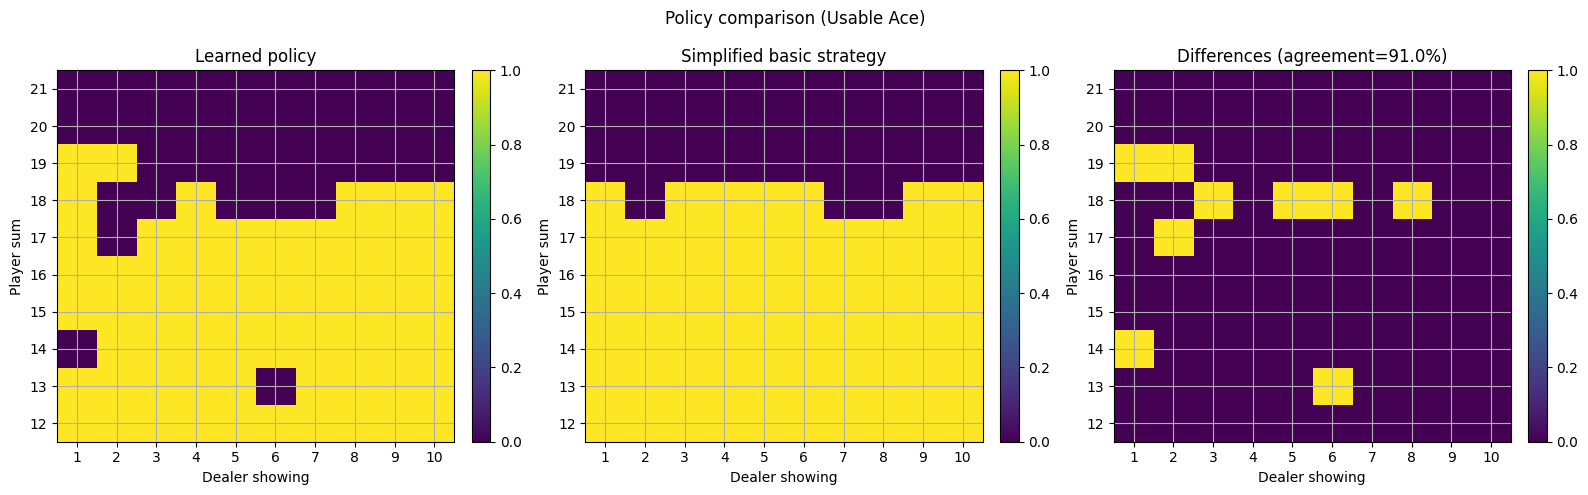

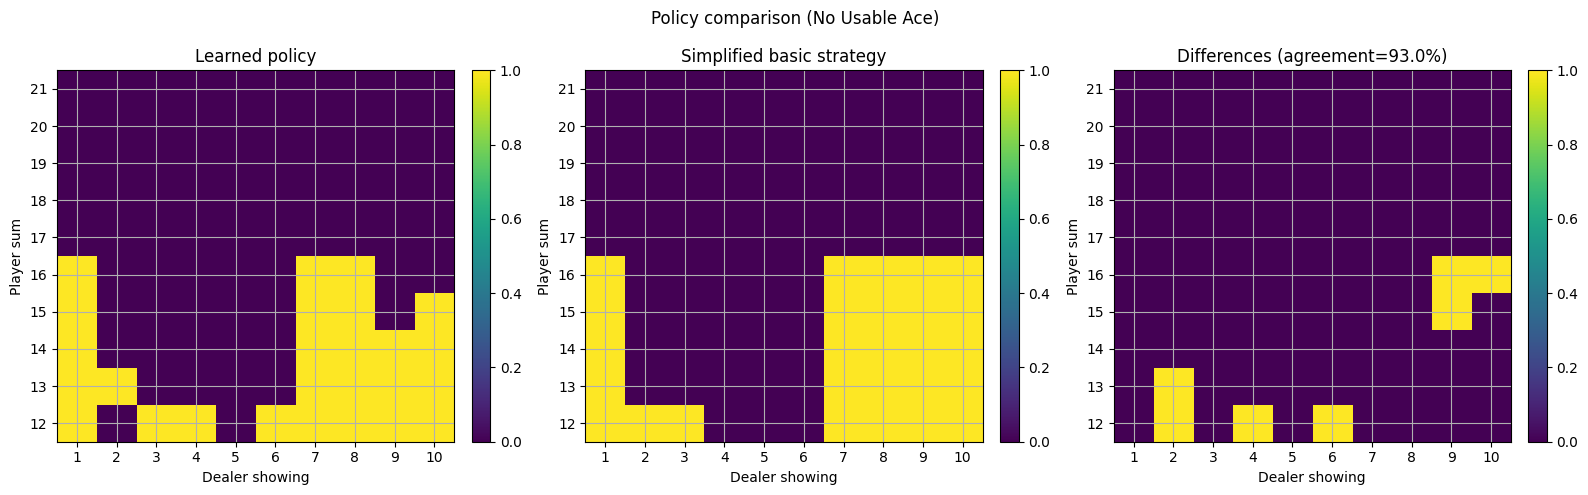

In [59]:

def plot_policy_comparison(learned_policy, usable_ace=True):
    learned, basic, match, agreement, diff_count = compare_policy_to_basic(
        learned_policy, usable_ace=usable_ace
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    im0 = axes[0].imshow(learned, origin="lower", aspect="auto")
    axes[0].set_title("Learned policy")
    axes[0].set_xlabel("Dealer showing")
    axes[0].set_ylabel("Player sum")

    im1 = axes[1].imshow(basic, origin="lower", aspect="auto")
    axes[1].set_title("Simplified basic strategy")
    axes[1].set_xlabel("Dealer showing")
    axes[1].set_ylabel("Player sum")

    im2 = axes[2].imshow(~match, origin="lower", aspect="auto")
    axes[2].set_title(f"Differences (agreement={agreement:.1%})")
    axes[2].set_xlabel("Dealer showing")
    axes[2].set_ylabel("Player sum")

    for ax in axes:
        ax.set_xticks(np.arange(10), labels=np.arange(1, 11))
        ax.set_yticks(np.arange(10), labels=np.arange(12, 22))

    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    fig.suptitle(f"Policy comparison ({'Usable Ace' if usable_ace else 'No Usable Ace'})")
    plt.tight_layout()
    plt.show()

plot_policy_comparison(main_results["policy"], usable_ace=True)
plot_policy_comparison(main_results["policy"], usable_ace=False)



## 6. Experiments with different ε values and decay schedules

The prompt asks for experiments with different ε settings.  
Below we compare three configurations:

1. **fixed ε = 0.10**
2. **fixed ε = 0.05**
3. **linear decay: 0.10 → 0.01**

To keep the comparison notebook practical, you can change the number of episodes for these experiments. The main assignment run above already used **500,000 episodes**.


In [60]:

experiment_configs = [
    {
        "name": "fixed_0.10",
        "schedule_type": "fixed",
        "epsilon_start": 0.10,
        "epsilon_end": 0.10,
        "decay_fraction": 1.0,
        "seed": 101,
    },
    {
        "name": "fixed_0.05",
        "schedule_type": "fixed",
        "epsilon_start": 0.05,
        "epsilon_end": 0.05,
        "decay_fraction": 1.0,
        "seed": 102,
    },
    {
        "name": "linear_0.10_to_0.01",
        "schedule_type": "linear",
        "epsilon_start": 0.10,
        "epsilon_end": 0.01,
        "decay_fraction": 0.8,
        "seed": 103,
    },
]

# You may increase this to 500_000 for each experiment if you want a heavier comparison.
experiment_episodes = 150_000
experiment_results = {}

for cfg in experiment_configs:
    print(" " + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("=" * 80)

    result = first_visit_mc_control(
        env=env,
        n_episodes=experiment_episodes,
        gamma=1.0,
        schedule_type=cfg["schedule_type"],
        epsilon_start=cfg["epsilon_start"],
        epsilon_end=cfg["epsilon_end"],
        decay_fraction=cfg["decay_fraction"],
        seed=cfg["seed"],
        log_every=50_000,
    )
    experiment_results[cfg["name"]] = result


Running experiment: fixed_0.10
Episode       1 | epsilon=0.1000 | recent avg return=-1.0000 | recent avg length=2.00 | visited states=   2 | elapsed=0.0s
Episode  50,000 | epsilon=0.1000 | recent avg return=-0.1118 | recent avg length=1.46 | visited states= 280 | elapsed=1.5s
Episode 100,000 | epsilon=0.1000 | recent avg return=-0.0917 | recent avg length=1.48 | visited states= 280 | elapsed=3.0s
Episode 150,000 | epsilon=0.1000 | recent avg return=-0.0876 | recent avg length=1.49 | visited states= 280 | elapsed=4.5s
Running experiment: fixed_0.05
Episode       1 | epsilon=0.0500 | recent avg return=-1.0000 | recent avg length=2.00 | visited states=   2 | elapsed=0.0s
Episode  50,000 | epsilon=0.0500 | recent avg return=-0.0978 | recent avg length=1.40 | visited states= 280 | elapsed=1.4s
Episode 100,000 | epsilon=0.0500 | recent avg return=-0.0919 | recent avg length=1.44 | visited states= 280 | elapsed=3.0s
Episode 150,000 | epsilon=0.0500 | recent avg return=-0.0817 | recent avg len

In [61]:

summary_rows = []
for name, result in experiment_results.items():
    r = result["episode_returns"]
    learned, basic_u, match_u, agree_u, diff_u = compare_policy_to_basic(result["policy"], usable_ace=True)
    learned, basic_n, match_n, agree_n, diff_n = compare_policy_to_basic(result["policy"], usable_ace=False)

    summary_rows.append({
        "config": name,
        "episodes": len(r),
        "mean_return": float(r.mean()),
        "win_rate": float((r == 1).mean()),
        "draw_rate": float((r == 0).mean()),
        "loss_rate": float((r == -1).mean()),
        "agreement_usable_ace": float(agree_u),
        "agreement_no_usable_ace": float(agree_n),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_return", ascending=False)
display(summary_df)


,config,episodes,mean_return,win_rate,draw_rate,loss_rate,agreement_usable_ace,agreement_no_usable_ace
2,linear_0.10_to_0.01,150000,-0.089113,0.415500,0.079887,0.504613,0.88,0.86
1,fixed_0.05,150000,-0.090480,0.415540,0.078440,0.506020,0.81,0.88
0,fixed_0.10,150000,-0.097000,0.410667,0.081667,0.507667,0.84,0.93


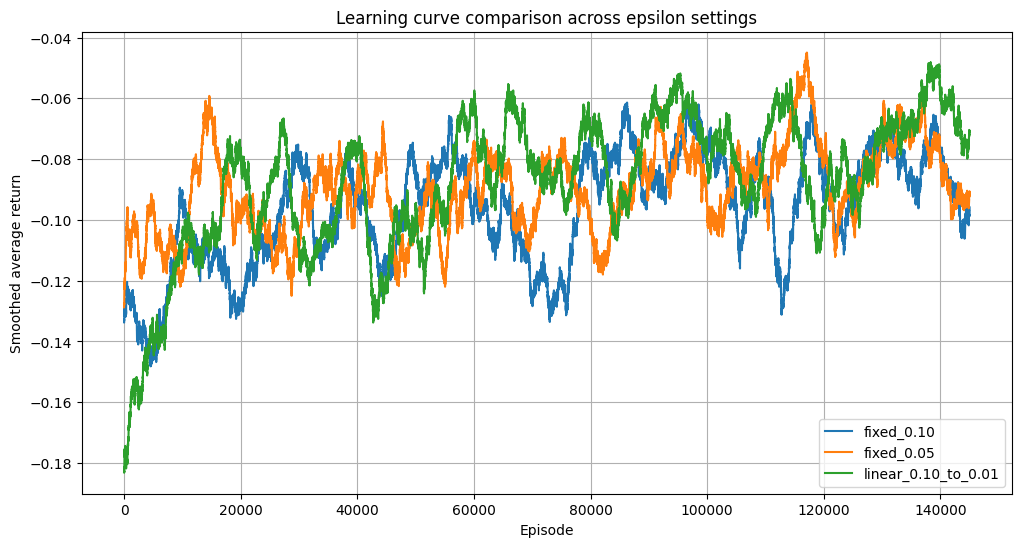

In [62]:

plt.figure(figsize=(12, 6))
for name, result in experiment_results.items():
    sm = moving_average(result["episode_returns"], window=5_000)
    plt.plot(np.arange(1, len(sm) + 1), sm, label=name)

plt.title("Learning curve comparison across epsilon settings")
plt.xlabel("Episode")
plt.ylabel("Smoothed average return")
plt.legend()
plt.show()


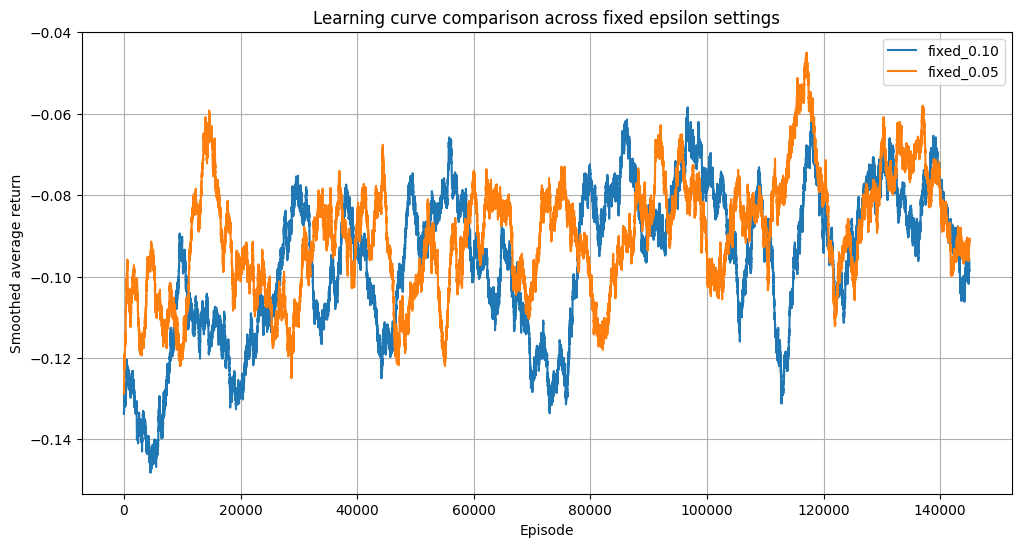

In [66]:


plt.figure(figsize=(12, 6))




for name, result in list(experiment_results.items())[:2]:
    sm = moving_average(result["episode_returns"], window=5_000)
    plt.plot(np.arange(1, len(sm) + 1), sm, label=name)

plt.title("Learning curve comparison across fixed epsilon settings")
plt.xlabel("Episode")
plt.ylabel("Smoothed average return")
plt.legend()
plt.show()


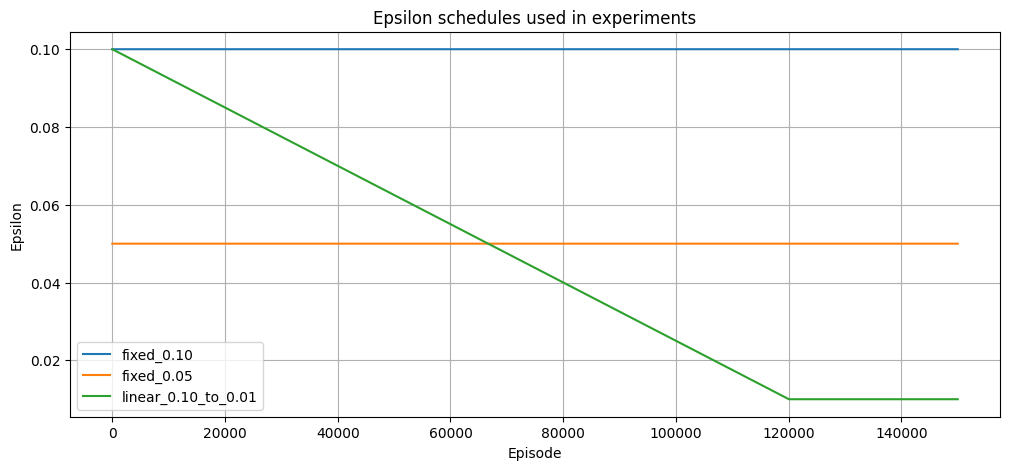

In [64]:

plt.figure(figsize=(12, 5))
for name, result in experiment_results.items():
    plt.plot(result["epsilon_history"], label=name)

plt.title("Epsilon schedules used in experiments")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.show()
